In [ ]:
!pip install grad-cam

Configuration

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from google.colab import drive
from tqdm import tqdm
import time
from sklearn.metrics import accuracy_score,precision_recall_fscore_support,classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

batch_size = 32
epochs = 50
lr = 1e-3

Device: cuda


Connect Drive to locate output

In [ ]:

drive.mount('/content/drive')
print(os.listdir("/content/drive"))
os.makedirs("/content/drive/MyDrive/models", exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['MyDrive', '.shortcut-targets-by-id', '.Trash-0', '.Encrypted']


DenseNet Architecture

In [ ]:
# Bottle Neck Layer
class Bottleneck(nn.Module):
    def __init__(self, in_channels, growth_rate):
        super().__init__()
        inter_channels = 4 * growth_rate

        self.bn1 = nn.BatchNorm2d(in_channels)
        self.conv1 = nn.Conv2d(in_channels, inter_channels, kernel_size=1, bias=False)

        self.bn2 = nn.BatchNorm2d(inter_channels)
        self.conv2 = nn.Conv2d(inter_channels, growth_rate, kernel_size=3, padding=1, bias=False)

    def forward(self, x):
        out = self.conv1(F.relu(self.bn1(x)))
        out = self.conv2(F.relu(self.bn2(out)))
        return torch.cat([x, out], 1)

# Dense Block
class DenseBlock(nn.Module):
    def __init__(self, num_layers, in_channels, growth_rate):
        super().__init__()
        layers = []

        for i in range(num_layers):
            layers.append(Bottleneck(in_channels + i * growth_rate, growth_rate))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

# Transition Layer
class Transition(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.bn = nn.BatchNorm2d(in_channels)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.conv(F.relu(self.bn(x)))
        x = self.pool(x)
        return x

# DenseNet
class DenseNet(nn.Module):
    def __init__(self, block_config=(6, 12, 24, 16), growth_rate=32, reduction=0.5, num_classes=5):
        super().__init__()

        num_init_features = 2 * growth_rate

        # First conv
        self.features = nn.Sequential(
            nn.Conv2d(3, num_init_features, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(num_init_features),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        num_features = num_init_features

        # Dense blocks
        for i, num_layers in enumerate(block_config):
            block = DenseBlock(num_layers, num_features, growth_rate)
            self.features.add_module(f"denseblock{i+1}", block)

            num_features += num_layers * growth_rate

            if i != len(block_config) - 1:
                out_features = int(num_features * reduction)
                trans = Transition(num_features, out_features)
                self.features.add_module(f"transition{i+1}", trans)
                num_features = out_features

        # Final BN
        self.features.add_module("norm5", nn.BatchNorm2d(num_features))

        # Classifier
        self.classifier = nn.Linear(num_features, num_classes)

        # Init weights
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.features(x)
        x = F.relu(x)

        x = F.adaptive_avg_pool2d(x, (1, 1))
        x = torch.flatten(x, 1)

        x = self.classifier(x)
        return x


def densenet121(num_classes=5):
    return DenseNet(block_config=(6, 12, 24, 16), growth_rate=32, num_classes=num_classes)


Load Dataset

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

EDA

In [ ]:
print("Train:", len(train_dataset))
print("Test:", len(test_dataset))
print("Classes:", train_dataset.classes)

img, label = train_dataset[0]
print("Shape:", img.shape)
print("Number of labels:", label)

Train: 60000
Test: 10000
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Shape: torch.Size([3, 224, 224])
Number of labels: 9


Counter({tensor(9): 1, tensor(0): 1, tensor(0): 1, tensor(3): 1, tensor(0): 1, tensor(2): 1, tensor(7): 1, tensor(2): 1, tensor(5): 1, tensor(5): 1, tensor(0): 1, tensor(9): 1, tensor(5): 1, tensor(5): 1, tensor(7): 1, tensor(9): 1, tensor(1): 1, tensor(0): 1, tensor(6): 1, tensor(4): 1, tensor(3): 1, tensor(1): 1, tensor(4): 1, tensor(8): 1, tensor(4): 1, tensor(3): 1, tensor(0): 1, tensor(2): 1, tensor(4): 1, tensor(4): 1, tensor(5): 1, tensor(3): 1, tensor(6): 1, tensor(6): 1, tensor(0): 1, tensor(8): 1, tensor(5): 1, tensor(2): 1, tensor(1): 1, tensor(6): 1, tensor(6): 1, tensor(7): 1, tensor(9): 1, tensor(5): 1, tensor(9): 1, tensor(2): 1, tensor(7): 1, tensor(3): 1, tensor(0): 1, tensor(3): 1, tensor(3): 1, tensor(3): 1, tensor(7): 1, tensor(2): 1, tensor(2): 1, tensor(6): 1, tensor(6): 1, tensor(8): 1, tensor(3): 1, tensor(3): 1, tensor(5): 1, tensor(0): 1, tensor(5): 1, tensor(5): 1, tensor(0): 1, tensor(2): 1, tensor(0): 1, tensor(0): 1, tensor(4): 1, tensor(1): 1, tensor(3): 

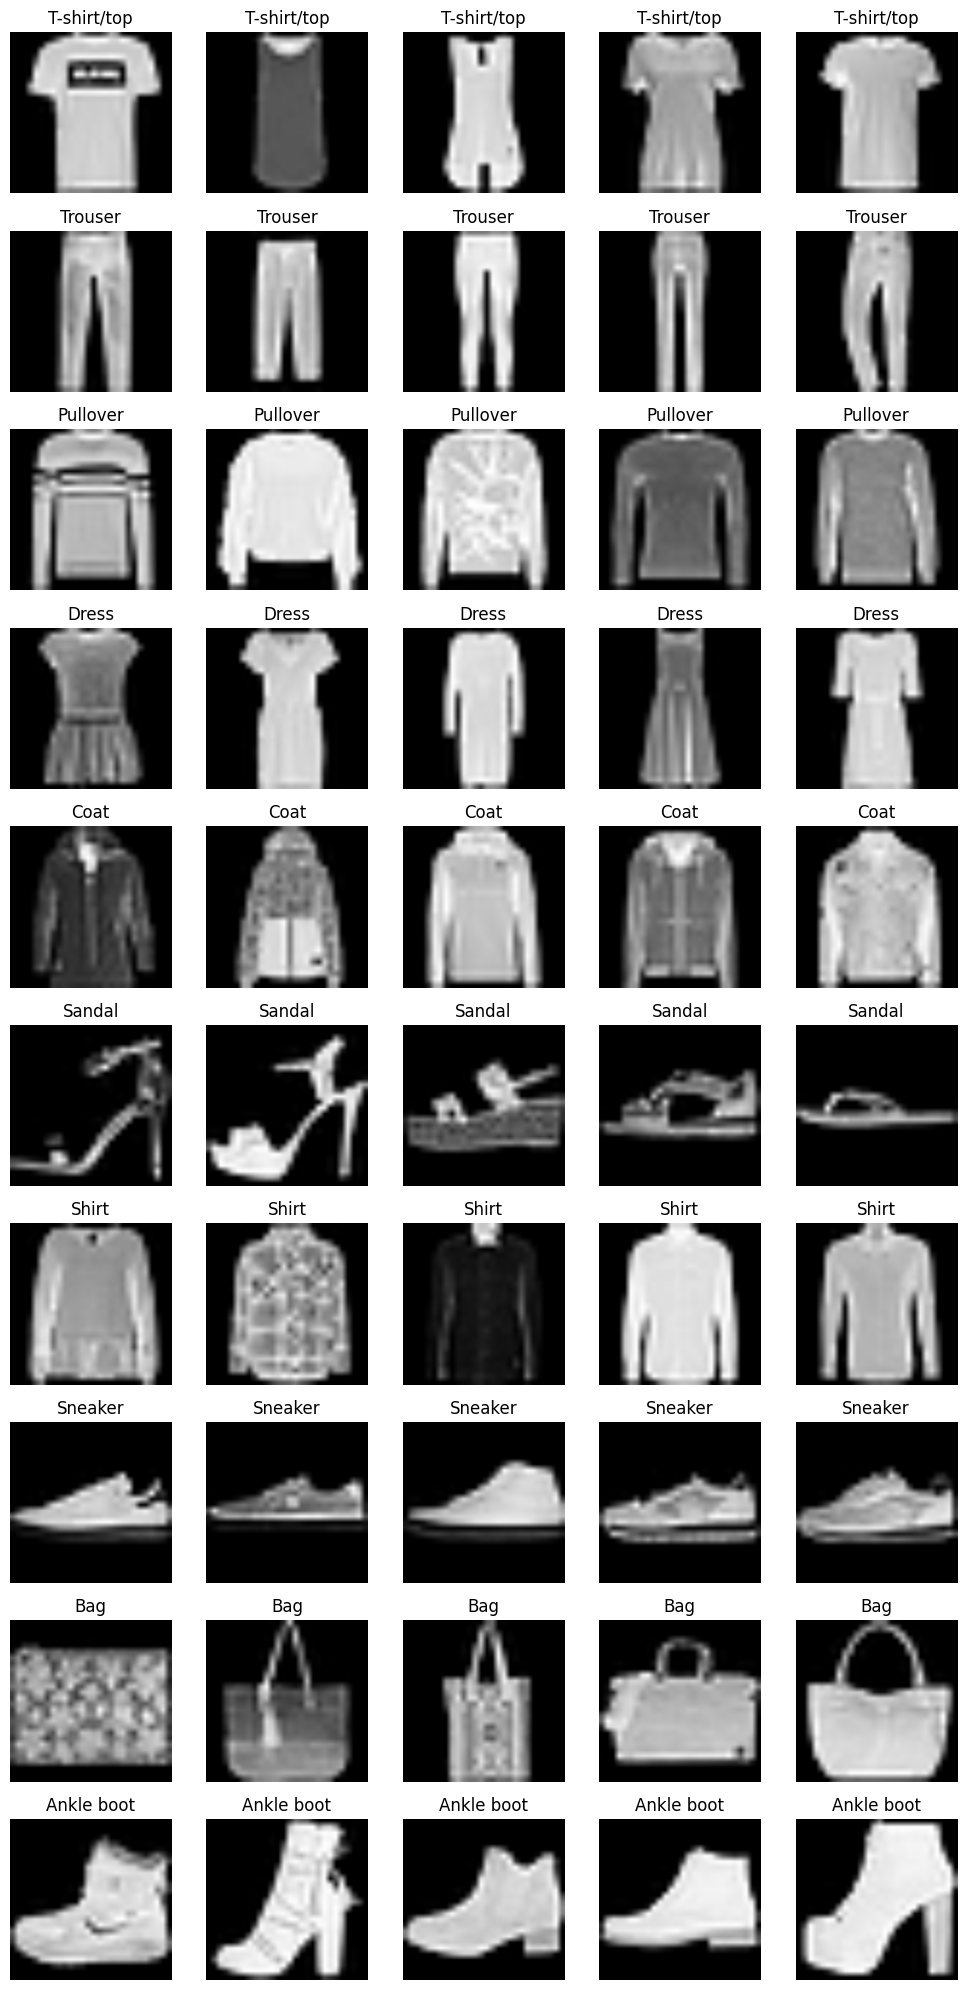

In [ ]:


class_names = train_dataset.classes
print(Counter(train_dataset.targets))


def show_samples_per_class(dataset, samples_per_class=5):
    num_classes = len(class_names)

    fig, axes = plt.subplots(num_classes, samples_per_class,
                             figsize=(samples_per_class * 2, num_classes * 2))

    if samples_per_class == 1:
        axes = axes.reshape(num_classes, 1)

    class_count = {i: 0 for i in range(num_classes)}

    for img, label in dataset:
        if class_count[label] < samples_per_class:
            row = label
            col = class_count[label]

            ax = axes[row, col]

            img = img.numpy().transpose(1, 2, 0)


            mean = np.array([0.5] * img.shape[2])
            std = np.array([0.5] * img.shape[2])
            img = img * std + mean
            img = np.clip(img, 0, 1)

            if img.shape[2] == 1:
                img = img.squeeze()
                ax.imshow(img, cmap='gray')
            else:
                ax.imshow(img)

            ax.set_title(class_names[label])
            ax.axis("off")

            class_count[label] += 1


        if all(v == samples_per_class for v in class_count.values()):
            break

    plt.tight_layout()
    plt.show()


show_samples_per_class(train_dataset, samples_per_class=5)

Class distribution:
Ankle boot: 6000
T-shirt/top: 6000
Dress: 6000
Pullover: 6000
Sneaker: 6000
Sandal: 6000
Trouser: 6000
Shirt: 6000
Coat: 6000
Bag: 6000


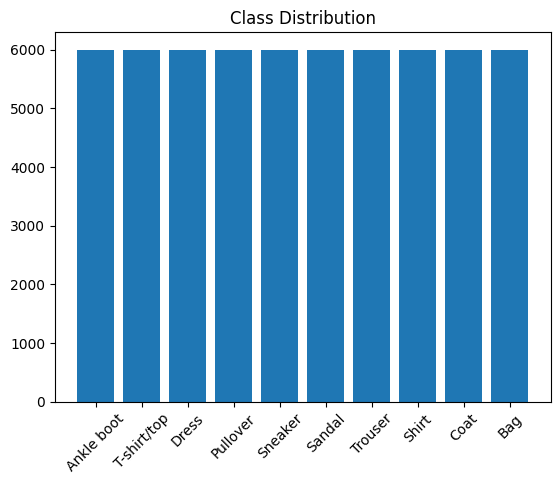

In [ ]:
import matplotlib.pyplot as plt

targets = train_dataset.targets.numpy()
count = Counter(targets)

print("Class distribution:")
for k, v in count.items():
    print(f"{class_names[k]}: {v}")

# plot
plt.bar([class_names[i] for i in count.keys()], count.values())
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

Train code

In [ ]:

# Train
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)   # logits
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = correct / total
    return total_loss / len(loader), acc

# Evaluation
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

In [ ]:
model = densenet121(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

Traing phase

In [ ]:


# ===== MOUNT DRIVE =====
if not os.path.exists("/content/drive"):
    from google.colab import drive
    drive.mount('/content/drive')

os.makedirs("/content/drive/MyDrive/models", exist_ok=True)

checkpoint_path = "/content/drive/MyDrive/models/checkpoint.pth"
best_model_path = "/content/drive/MyDrive/models/best_model.pth"

# ===== RESUME =====
start_epoch = 0
best_acc = 0

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_acc = checkpoint['best_acc']

    print(f"Resume from epoch {start_epoch}, best_acc={best_acc:.4f}")

# ===== TRAIN =====
start_time = time.time()

for epoch in range(start_epoch, epochs):
    epoch_start = time.time()

    # ---- TRAIN ----
    model.train()
    total_loss, correct, total = 0, 0, 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]")

    for images, labels in train_bar:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        # update progress bar
        train_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{correct/total:.4f}"
        })

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    # ---- TEST ----
    model.eval()
    correct, total = 0, 0

    test_bar = tqdm(test_loader, desc=f"Epoch {epoch+1} [Test]")

    with torch.no_grad():
        for images, labels in test_bar:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            test_bar.set_postfix({
                "acc": f"{correct/total:.4f}"
            })

    test_acc = correct / total

    epoch_time = time.time() - epoch_start
    total_time = time.time() - start_time
    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Test Acc: {test_acc:.4f}")
    print(f"Epoch Time: {epoch_time:.2f}s | Total Time: {total_time/60:.2f} min")
    print("-" * 50)

    # ---- SAVE BEST ----
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), best_model_path)
        print("Saved BEST model!")

    # ---- SAVE CHECKPOINT ----
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_acc': best_acc
    }, checkpoint_path)

Resume from epoch 50, best_acc=0.9428


Testing Phase

In [ ]:

all_preds = []
all_labels = []
wrong_images = []
wrong_true = []
wrong_pred = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)          # logits
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        mask = preds != labels

        wrong_images.extend(images[mask].cpu())
        wrong_true.extend(labels[mask].cpu())
        wrong_pred.extend(preds[mask].cpu())


acc = accuracy_score(all_labels, all_preds)
print("Accuracy:", acc)



precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels,
    all_preds,
    average="macro"
)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print(classification_report(all_labels, all_preds))

Accuracy: 0.9411
Precision: 0.9410743861468527
Recall: 0.9410999999999999
F1-score: 0.9409675791153438
              precision    recall  f1-score   support

           0       0.89      0.90      0.90      1000
           1       1.00      0.99      0.99      1000
           2       0.93      0.90      0.92      1000
           3       0.93      0.95      0.94      1000
           4       0.90      0.94      0.92      1000
           5       0.99      0.99      0.99      1000
           6       0.84      0.82      0.83      1000
           7       0.96      0.98      0.97      1000
           8       0.99      0.99      0.99      1000
           9       0.98      0.96      0.97      1000

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



Confusion matrix

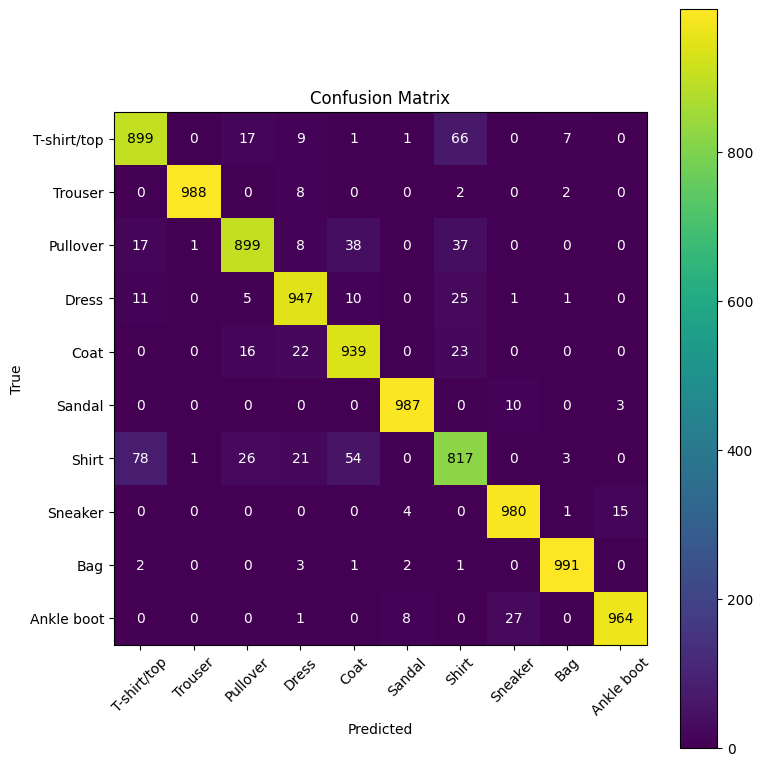

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 8))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

classes = train_dataset.classes

tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center",
                 color="black" if cm[i, j] > cm.max()/2 else "white")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

Wrong Image

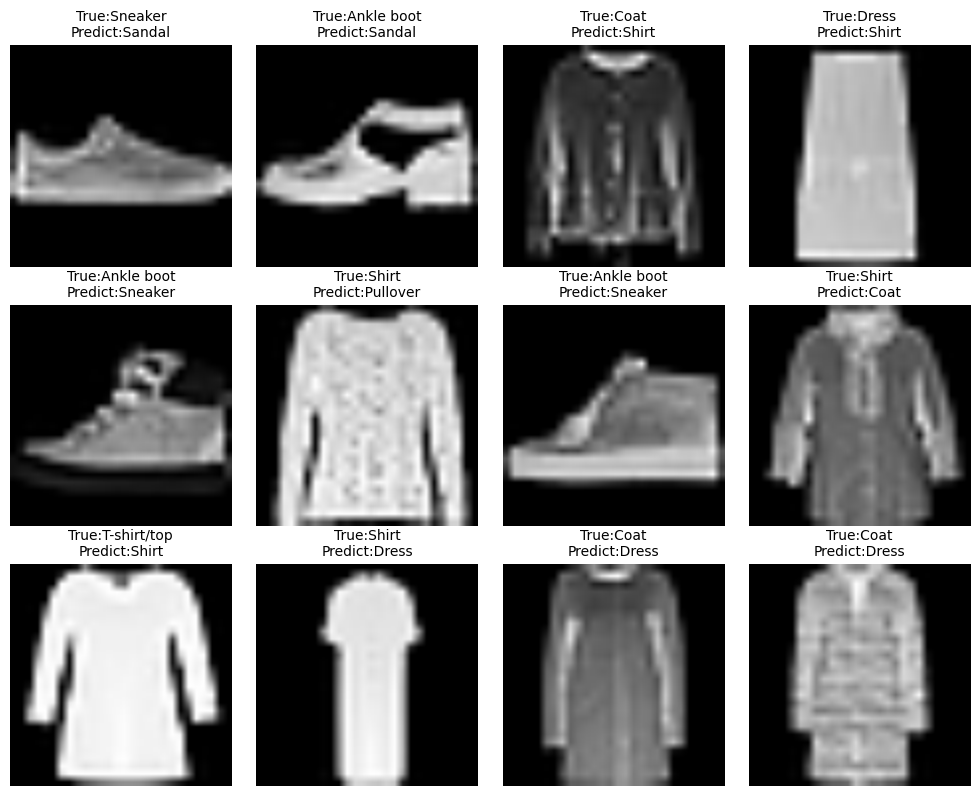

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(10, 8))

classes = train_dataset.classes
num_show = min(12, len(wrong_images))

for i in range(num_show):
    img = wrong_images[i].permute(1, 2, 0).cpu().numpy()

    mean = np.array([0.5] * img.shape[2])
    std = np.array([0.5] * img.shape[2])
    img = img * std + mean
    img = np.clip(img, 0, 1)

    ax = axes[i // 4, i % 4]

    if img.shape[2] == 1:
        img = img.squeeze()
        ax.imshow(img, cmap='gray')
    else:
        ax.imshow(img)
    true_label = classes[wrong_true[i]]
    pred_label = classes[wrong_pred[i]]

    ax.set_title(f"True:{true_label}\nPredict:{pred_label}", fontsize=10)
    ax.axis("off")

for j in range(num_show, 12):
    axes[j // 4, j % 4].axis("off")

plt.tight_layout()
plt.show()

Interpretability

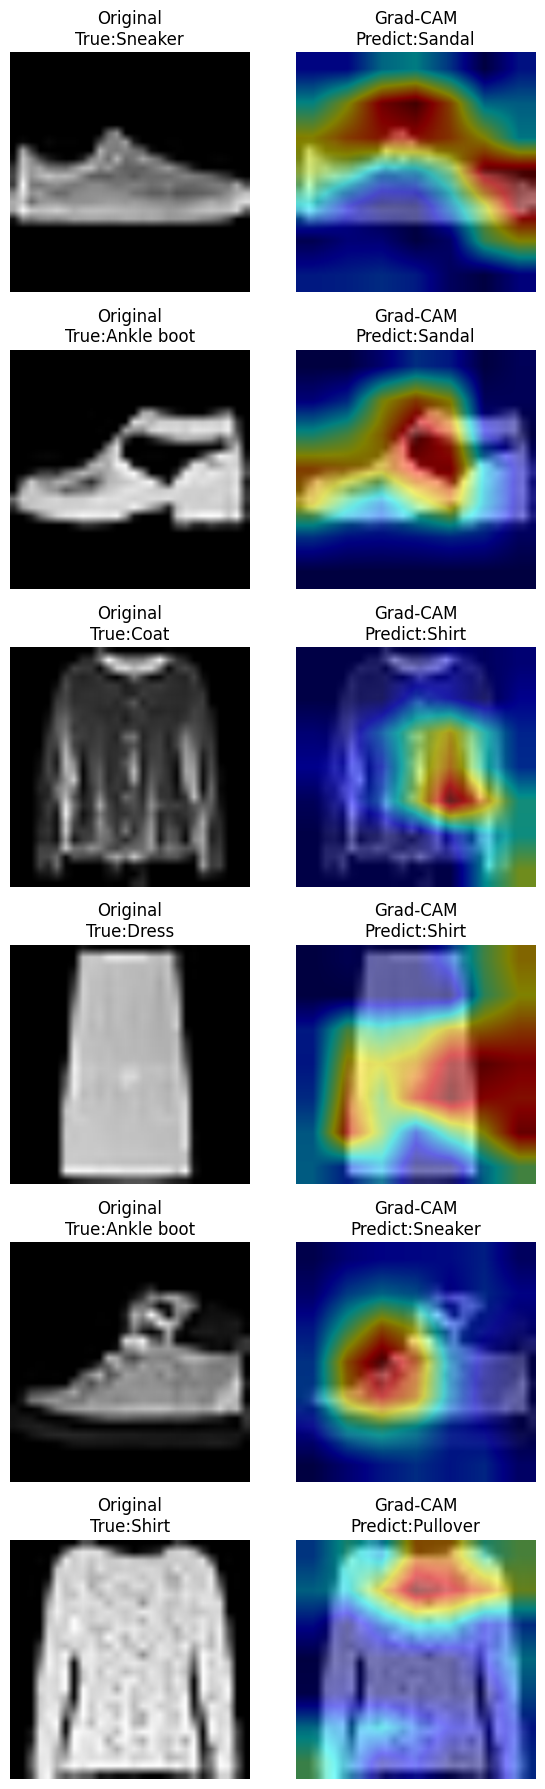

In [ ]:

model.eval()


target_layer = model.features[-1]

cam = GradCAM(model=model, target_layers=[target_layer])

classes = train_dataset.classes

num_show = min(6, len(wrong_images))

fig, axes = plt.subplots(num_show, 2, figsize=(6, num_show * 3))

for i in range(num_show):
    img_tensor = wrong_images[i].unsqueeze(0).to(device)

    true_label = wrong_true[i].item()
    pred_label = wrong_pred[i].item()

    target = [ClassifierOutputTarget(pred_label)]

    # Grad-CAM
    grayscale_cam = cam(input_tensor=img_tensor, targets=target)[0]

    # ===== ảnh gốc =====
    img = wrong_images[i].permute(1, 2, 0).cpu().numpy()

    mean = np.array([0.5] * img.shape[2])
    std = np.array([0.5] * img.shape[2])
    img = img * std + mean
    img = np.clip(img, 0, 1)

    # nếu grayscale
    if img.shape[2] == 1:
        img_show = img.squeeze()
        axes[i, 0].imshow(img_show, cmap='gray')
    else:
        axes[i, 0].imshow(img)

    axes[i, 0].set_title(f"Original\nTrue:{classes[true_label]}")
    axes[i, 0].axis("off")

    # ===== Grad-CAM overlay =====
    cam_img = show_cam_on_image(img.astype(np.float32), grayscale_cam, use_rgb=True)

    axes[i, 1].imshow(cam_img)
    axes[i, 1].set_title(f"Grad-CAM\nPredict:{classes[pred_label]}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

Robustness Test

In [ ]:
def add_noise(images, std=0.1):
    noise = torch.randn_like(images) * std
    noisy_images = images + noise
    return torch.clamp(noisy_images, -1, 1)

def evaluate_with_perturbation(model, dataloader, device, perturb_fn=None):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            if perturb_fn is not None:
                images = perturb_fn(images)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total


clean_acc = evaluate_with_perturbation(model, test_loader, device)
noise_acc = evaluate_with_perturbation(
    model, test_loader, device,
    perturb_fn=lambda x: add_noise(x, std=0.1)
)

print(f"Clean Acc: {clean_acc:.4f}")
print(f"Noise Acc: {noise_acc:.4f}")
print(f"Drop: {(clean_acc - noise_acc)*100:.2f}%")

Clean Acc: 0.9411
Noise Acc: 0.9042
Drop: 3.69%


Efficiency

In [ ]:
#Parameter Counting
def count_params(model):
    return sum(p.numel() for p in model.parameters())

params = count_params(model)
print(f"Total parameters: {params/1e6:.2f}M")


#Inference Time
def measure_inference_time(model, dataloader, device, num_batches=50):
    model.eval()
    total_time = 0
    count = 0

    with torch.no_grad():
        for i, (images, _) in enumerate(dataloader):
            if i >= num_batches:
                break

            images = images.to(device)

            start = time.time()
            _ = model(images)
            end = time.time()

            total_time += (end - start)
            count += 1

    return total_time / count

avg_time = measure_inference_time(model, test_loader, device)
print(f"Avg inference time per batch: {avg_time*1000:.2f} ms")

Total parameters: 6.96M
Avg inference time per batch: 97.11 ms
